# Text Analysis: Descriptions, Resolutions & Survey Responses

This notebook analyzes the three free-text fields available across the work task dataset: `DESCRIPTION` (written by the requester at ticket submission), `RESOLUTION_DESCRIPTION` (written by the technician upon completion), and `RESPONSE_COMMENTS` (collected from post-completion customer surveys). Coverage varies considerably across fields — many tickets have no description at all, and survey responses exist for only a small subset.

We approach the text data from two angles:
1. **Sentiment Analysis** — scoring the emotional tone of each text field to identify unusually positive or negative tickets across service and request classes.
2. **Keyword Frequency** — surfacing the most common vocabulary within each `REQUEST_CLASS` and `SERVICE_CLASS` to better understand what language characterizes different categories of work.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
df_assets = pd.read_csv("../../data/V_OM_WORK_TASK_ASSET.csv")
df_space = pd.read_csv("../../data/V_SPACE_DETAIL.csv")
df_survey = pd.read_csv("../../data/V_OM_WORK_TASK_SURVEY.csv")

/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_11942/3837918910.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tickets = pd.read_csv("../../data/V_OM_WORK_TASK.csv")
/var/folders/y2/tsyh3wpj3mj7zcv4hfd0knl40000gn/T/ipykernel_11942/3837918910.py:5: DtypeWarning: Columns (0,3,4,5,6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df_assets = pd.read_csv("../../data/V_OM_WORK_TASK_ASSET.csv")


In [2]:
print('Tickets Columns:')
print(df_tickets.dtypes)
print('Assets Columns')
print(df_assets.dtypes)
print('Tickets Volume')
df_tickets.shape

Tickets Columns:
WORK_TASK_ID                      object
WORK_TASK_NAME                    object
WORK_TASK_STATUS                  object
RICE_WORK_STATUS                  object
ASSIGNMENT_STATUS                 object
DESCRIPTION                       object
TASK_TYPE                         object
TASK_PRIORITY                     object
REQUEST_CLASS                     object
SERVICE_CLASS                     object
PRIMARY_LOCATION                  object
PROPERTY                          object
BUILDING                          object
FLOOR                             object
SPACE                             object
GEOGRAPHY_LOOKUP                  object
CUSTOMER_ORGANIZATION             object
CUSTOMER_COMPANY                  object
CUSTOMER_DIVISION                 object
CUSTOMER_DEPARTMENT               object
RESPONSIBLE_ORGANIZATION_NAME     object
ORGANIZATION_TYPE                 object
RESPONSIBLE_ORGANIZATION_PATH     object
RESPONSIBLE_PERSON_NAME           object

(227554, 47)

## Data Preparation

The working dataframe is built by joining three data sources on `WORK_TASK_ID`: the core ticket table (`df_tickets`), the asset table (`df_assets`), and the customer survey table (`df_survey`). A few deduplication decisions shape this merge:

- `df_assets` is deduplicated to one row per ticket before joining, since a work task can be linked to multiple assets and we only need one asset record for identification purposes.
- `df_survey` is similarly reduced to one response per ticket (dropping null `WORK_TASK_ID`s first), retaining only the `RESPONSE_COMMENTS` field.
- `BUILDING_CLASS` is derived from `df_space` via a lookup on building name, adding a higher-level classification of building type to each ticket.

Both joins are left joins anchored to `df_tickets`, so the row count of `merged_df` stays at the ~227k tickets in the base table. Survey responses cover only a small fraction of tickets (~9,800), so `RESPONSE_COMMENTS` will be sparse in the merged frame. The merged dataframe is then narrowed to 24 relevant columns before analysis begins.

In [3]:
df_assets = df_assets.drop_duplicates(subset="WORK_TASK_ID", keep="first")
print("ASSETS SHAPE: ", df_assets.shape)
print("Tickets Shape: ", df_tickets.shape)

df_survey_unique = (
  df_survey
    .dropna(subset=["WORK_TASK_ID"])
    .drop_duplicates(subset="WORK_TASK_ID", keep="first")
    [["WORK_TASK_ID", "RESPONSE_COMMENTS"]]
)

print(f"df_survey shape: {df_survey.shape}")
print(f"df_survey_unique shape: {df_survey_unique.shape}")

merged_df = pd.merge(df_tickets, df_assets, on='WORK_TASK_ID', how='left')
merged_df = pd.merge(merged_df, df_survey_unique, on='WORK_TASK_ID', how='left')

buildingclass_map = (
    df_space
      .dropna(subset=["BUILDING_DESC", "BUILDING_CLASS"])
      .drop_duplicates(subset=["BUILDING_DESC"])
      .set_index("BUILDING_DESC")["BUILDING_CLASS"]
)

merged_df["BUILDING_CLASS"] = merged_df["BUILDING"].map(buildingclass_map)
#merged_df.dropna(subset=["ASSET_ID"])
merged_df.to_csv("../outputs/ASSET_TASKS.csv", index=False)
df_survey_unique.to_csv("../outputs/survey_unique.csv", index=False)
print(merged_df.dtypes)
print(df_tickets.shape)
merged_df.shape


ASSETS SHAPE:  (227550, 9)
Tickets Shape:  (227554, 47)
df_survey shape: (45869, 25)
df_survey_unique shape: (9793, 2)
WORK_TASK_ID                        object
WORK_TASK_NAME_x                    object
WORK_TASK_STATUS_x                  object
RICE_WORK_STATUS                    object
ASSIGNMENT_STATUS                   object
DESCRIPTION                         object
TASK_TYPE                           object
TASK_PRIORITY                       object
REQUEST_CLASS                       object
SERVICE_CLASS                       object
PRIMARY_LOCATION                    object
PROPERTY                            object
BUILDING                            object
FLOOR                               object
SPACE                               object
GEOGRAPHY_LOOKUP                    object
CUSTOMER_ORGANIZATION               object
CUSTOMER_COMPANY                    object
CUSTOMER_DIVISION                   object
CUSTOMER_DEPARTMENT                 object
RESPONSIBLE_ORGANIZAT

(227554, 57)

In [4]:
# Reduced Subset of Relevant Features
selected_columns = [
    'WORK_TASK_ID',
    'WORK_TASK_NAME_x',
    'WORK_TASK_STATUS_x',
    'RICE_WORK_STATUS',
    'TASK_TYPE',
    'RESOLUTION_DESCRIPTION',
    'DESCRIPTION',
    'RESPONSE_COMMENTS',
    'TASK_PRIORITY',
    'REQUEST_CLASS',
    'SERVICE_CLASS',
    'PRIMARY_LOCATION',
    'BUILDING',
    'CUSTOMER_DEPARTMENT',
    'ASSET_ID',
    'ASSET_NAME',
    'ASSET_STATUS',
    'BUILDING_CLASS',
    'NUMBER_OF_ASSETS',
    'RESPONSIBLE_ORGANIZATION_NAME',
    'ORGANIZATION_TYPE',
    'ACTUAL_START_LTZ',
    'ACTUAL_END_LTZ',
    'RICE_ACTUAL_COST'
]

df = merged_df[selected_columns].copy()
df.dtypes


WORK_TASK_ID                      object
WORK_TASK_NAME_x                  object
WORK_TASK_STATUS_x                object
RICE_WORK_STATUS                  object
TASK_TYPE                         object
RESOLUTION_DESCRIPTION            object
DESCRIPTION                       object
RESPONSE_COMMENTS                 object
TASK_PRIORITY                     object
REQUEST_CLASS                     object
SERVICE_CLASS                     object
PRIMARY_LOCATION                  object
BUILDING                          object
CUSTOMER_DEPARTMENT               object
ASSET_ID                          object
ASSET_NAME                        object
ASSET_STATUS                      object
BUILDING_CLASS                    object
NUMBER_OF_ASSETS                   int64
RESPONSIBLE_ORGANIZATION_NAME     object
ORGANIZATION_TYPE                 object
ACTUAL_START_LTZ                  object
ACTUAL_END_LTZ                    object
RICE_ACTUAL_COST                 float64
dtype: object

## Sentiment Analysis

We score each text field using [VADER](https://github.com/cjhutto/vaderSentiment) (Valence Aware Dictionary and sEntiment Reasoner), a lexicon-based model well-suited to short, informal text. Each field is assigned a **compound score** ranging from -1.0 (most negative) to +1.0 (most positive), stored in a new column for each source field. Null or empty values are returned as `NaN` and excluded from downstream analysis.

Because VADER is rule-based rather than trained on facility management language, interpret these scores as directional signals rather than precise measurements. They're most informative at the extremes — surfacing tickets with unusually frustrated requesters or satisfied survey respondents — rather than drawing fine distinctions across the bulk of the distribution.

`print_sentiment_extremes()` below prints the top and bottom *n* rows for each field, which serves as a quick sanity check on whether the scoring is behaving reasonably.

In [ ]:
import sys
import os
sys.path.append(os.path.abspath('../utils'))

from sentiments import sentiment_score, print_sentiment_extremes

for col in ["DESCRIPTION", "RESOLUTION_DESCRIPTION", "RESPONSE_COMMENTS"]:
    df[f"{col}_SENTIMENT"] = df[col].apply(sentiment_score)

pd.set_option("display.max_colwidth", None)

print_sentiment_extremes(df, "DESCRIPTION")
print_sentiment_extremes(df, "RESOLUTION_DESCRIPTION")
print_sentiment_extremes(df, "RESPONSE_COMMENTS")

# Future maybe try Hugging Face sentiment analysis module next

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/beckedwards/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Top 5 DESCRIPTION sentiment
WORK_TASK_ID: 1300066
SERVICE_CLASS: Custodial
REQUEST_CLASS: Custodial Issues
DESCRIPTION: Dear Housing & Dining Maintenance Team,  I’m Yiqian Wang(yw218) from Duncan, Room 326. I would like to request assistance with replacing the current showerhead in my bathroom.  The previous resident had installed a different showerhead on the shower pipe, but it is attached too tightly for us to remove it by hand. We would greatly appreciate if someone could come by with the proper tools to help us remove it.  Additionally, if possible, we would be very grateful if the staff member could also help us install our own shower filter and showerhead in its place.  Please let us know if this is something that can be done, and when a maintenance worker might be available to assist after 2pm today. Thank you very much!  Best regards,  Yiqian Wang  Duncan College, Room 326  3466569277
DESCRIPTION_SENTIMENT: 0.9892
---------------------------------------------------------------

## Keyword Exploration

Sentiment captures *how* a ticket is written; keyword analysis captures *what* it's about. Here we tokenize the `DESCRIPTION` field and compute word frequencies grouped by `REQUEST_CLASS` and `SERVICE_CLASS`, which lets us surface the vocabulary most characteristic of each category.

Text is processed using `clean_and_tokenize()`, which:
- Lowercases and strips all punctuation and digits
- Removes stopwords and tokens shorter than 3 characters (with exceptions defined in `SHORT_KEEP`)
- Returns a list of filtered tokens stored in a new `TOKENS` column

The analysis below works on a reduced frame `df_text` that drops rows with null `DESCRIPTION`s and retains only the columns needed for grouping and tokenization.

In [ ]:
from sentiments import clean_and_tokenize, word_frequency, top_n_words_per_group

# Make a working copy
df_text = df[['DESCRIPTION',
              'REQUEST_CLASS',
              'SERVICE_CLASS',
              'RESPONSIBLE_ORGANIZATION_NAME']].copy()

# Drop null descriptions
df_text = df_text.dropna(subset=['DESCRIPTION'])

# Clean + tokenize
df_text['TOKENS'] = df_text['DESCRIPTION'].apply(clean_and_tokenize)

# word_frequency(df_text, 'REQUEST_CLASS').to_csv("WordCount_x_RequestClass.csv", index=False)
# word_frequency(df_text, 'SERVICE_CLASS').to_csv("WordCount_x_ServiceClass.csv", index=False)
# word_frequency(df_text, 'RESPONSIBLE_ORGANIZATION_NAME').to_csv("WordCount_x_RON.csv", index=False)

word_frequency(df_text).to_csv("../outputs/OverallWordCounts.csv", index=False)

top_rc = top_n_words_per_group(
    df_text,
    group_col="REQUEST_CLASS",
    n=5,
    output_csv="../outputs/Top5Words_x_ServiceClass.csv"
)

top_sc = top_n_words_per_group(
    df_text,
    group_col="SERVICE_CLASS",
    n=3,
    output_csv="../outputs/Top3Words_x_ServiceClass.csv"
)

### Keyword Appearance Rates by Request Class

Raw word counts are useful for exploring overall vocabulary but can be misleading when request classes differ dramatically in volume — a keyword appearing in 500 tickets means something very different in a class with 600 total tickets vs. one with 50,000.

The cell below computes a per-class **appearance rate**: the share of distinct tickets within each `REQUEST_CLASS` that contain a given keyword at least once. Each keyword is counted at most once per ticket regardless of how many times it appears in the description, so the metric reflects breadth of coverage rather than raw repetition. The result is exported to `outputs/KeywordTicketCounts_by_RequestClass.csv` for further review.

In [8]:
# Distinct ticket-level keyword counts within each REQUEST_CLASS
# Output columns:
# Request Class, Keyword, Ticket Count, Appearance Rate


# Build a ticket-level working frame without redoing tokenization
# Prefer WORK_TASK_ID if it exists in df; otherwise fall back to row index
if "WORK_TASK_ID" in df.columns:
    ticket_keywords = df.loc[df_text.index, ["WORK_TASK_ID", "REQUEST_CLASS"]].copy()
    ticket_id_col = "WORK_TASK_ID"
else:
    ticket_keywords = df_text[["REQUEST_CLASS"]].copy()
    ticket_keywords["WORK_TASK_ID"] = df_text.index
    ticket_id_col = "WORK_TASK_ID"

ticket_keywords["TOKENS"] = df_text["TOKENS"]

# Drop missing request classes
ticket_keywords = ticket_keywords.dropna(subset=["REQUEST_CLASS"]).copy()

# Count each keyword at most once per ticket
ticket_keywords["UNIQUE_TOKENS"] = ticket_keywords["TOKENS"].apply(lambda x: sorted(set(x)))

exploded = ticket_keywords[[ticket_id_col, "REQUEST_CLASS", "UNIQUE_TOKENS"]].explode("UNIQUE_TOKENS")
exploded = exploded.dropna(subset=["UNIQUE_TOKENS"]).rename(columns={"UNIQUE_TOKENS": "Keyword"})

# Distinct ticket count per request class + keyword
keyword_ticket_counts = (
    exploded.groupby(["REQUEST_CLASS", "Keyword"])[ticket_id_col]
    .nunique()
    .reset_index(name="Ticket Count")
)

# Total distinct tickets per request class
request_class_totals = (
    ticket_keywords.groupby("REQUEST_CLASS")[ticket_id_col]
    .nunique()
    .reset_index(name="Total Tickets in Request Class")
)

# Merge and compute appearance rate
keyword_ticket_counts = keyword_ticket_counts.merge(
    request_class_totals,
    on="REQUEST_CLASS",
    how="left"
)

keyword_ticket_counts["Appearance Rate"] = (
    keyword_ticket_counts["Ticket Count"]
    / keyword_ticket_counts["Total Tickets in Request Class"].astype(float)
)

keyword_ticket_counts["Total Tickets in Request Class"] = (
    keyword_ticket_counts["Total Tickets in Request Class"]
    .astype(int))

# Final formatting
keyword_ticket_counts = (
    keyword_ticket_counts.rename(columns={
        "REQUEST_CLASS": "Request Class",
        "Keyword": "Keyword"
    })[
        ["Request Class", "Keyword", "Ticket Count", "Total Tickets in Request Class",  "Appearance Rate"]
    ]
    .sort_values(["Request Class", "Ticket Count", "Keyword"], ascending=[True, False, True])
    .reset_index(drop=True)
)

# Optional rounding for cleaner CSV
keyword_ticket_counts["Appearance Rate"] = keyword_ticket_counts["Appearance Rate"].round(2)

# Save
output_csv = "../outputs/KeywordTicketCounts_by_RequestClass.csv"
keyword_ticket_counts.to_csv(output_csv, index=False)

### Visualizing Top Words Across High-Volume Groups

Finally, we visualize keyword distributions for the five highest-volume groups within both `REQUEST_CLASS` and `SERVICE_CLASS`. Two chart types are generated for each:

- **Bar charts** — one subplot per group, showing the top words sorted by count. Good for reading individual group vocabulary at a glance.
- **Heatmaps** — words as rows, groups as columns, with column-wise normalization applied so that groups of very different sizes remain visually comparable. Useful for spotting vocabulary that is shared across categories vs. distinctive to one.

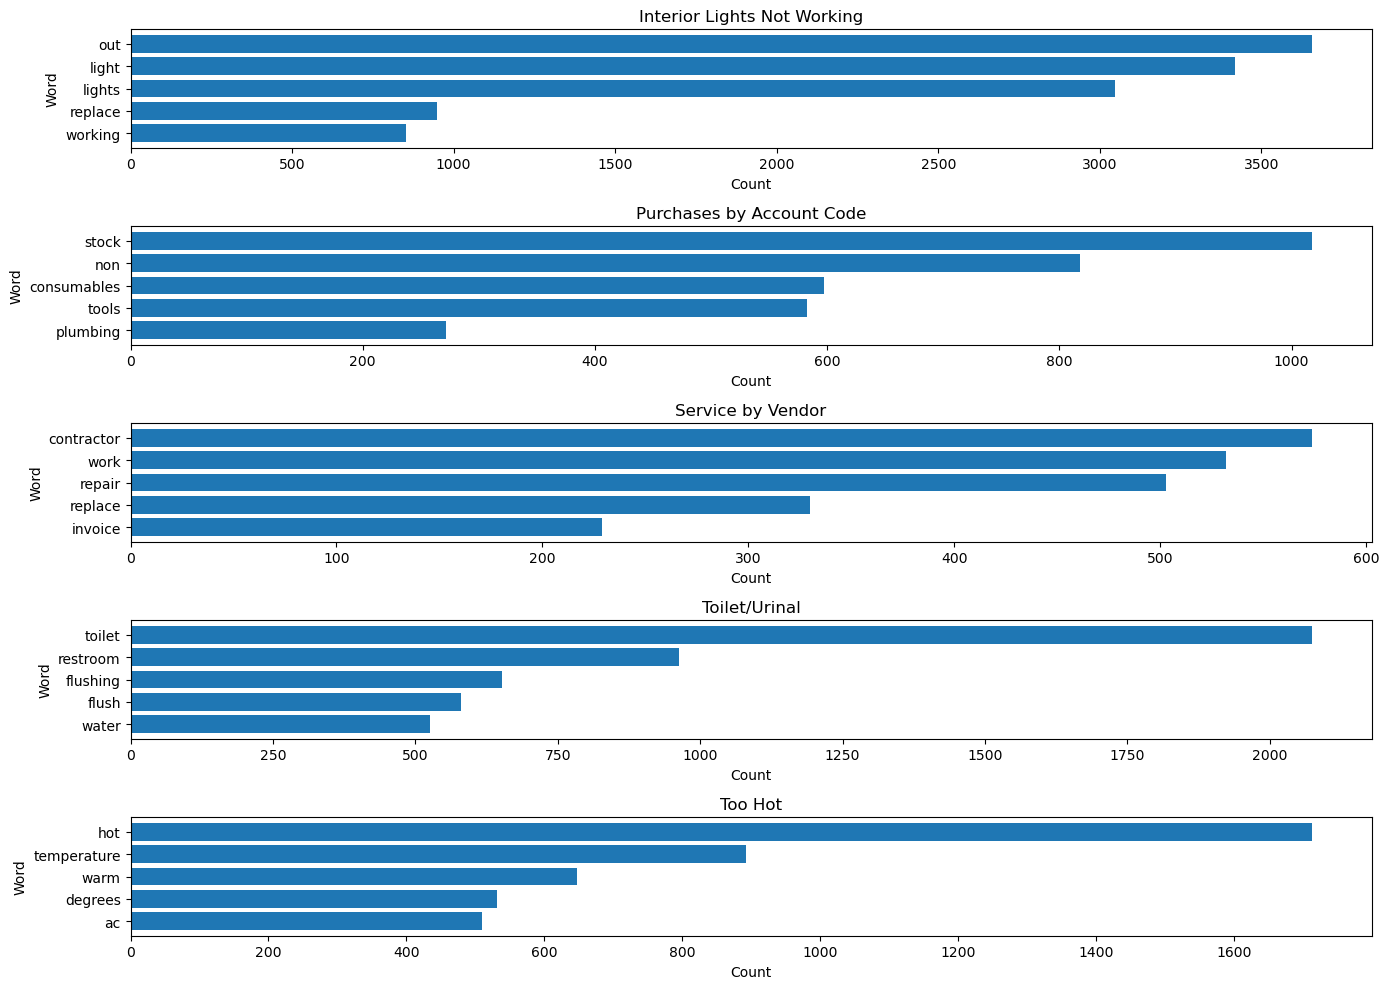

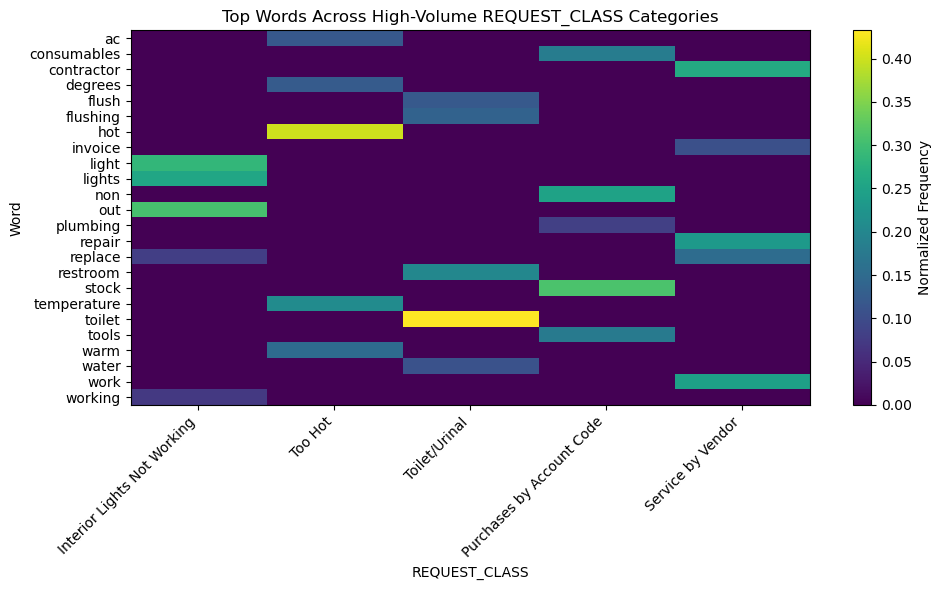

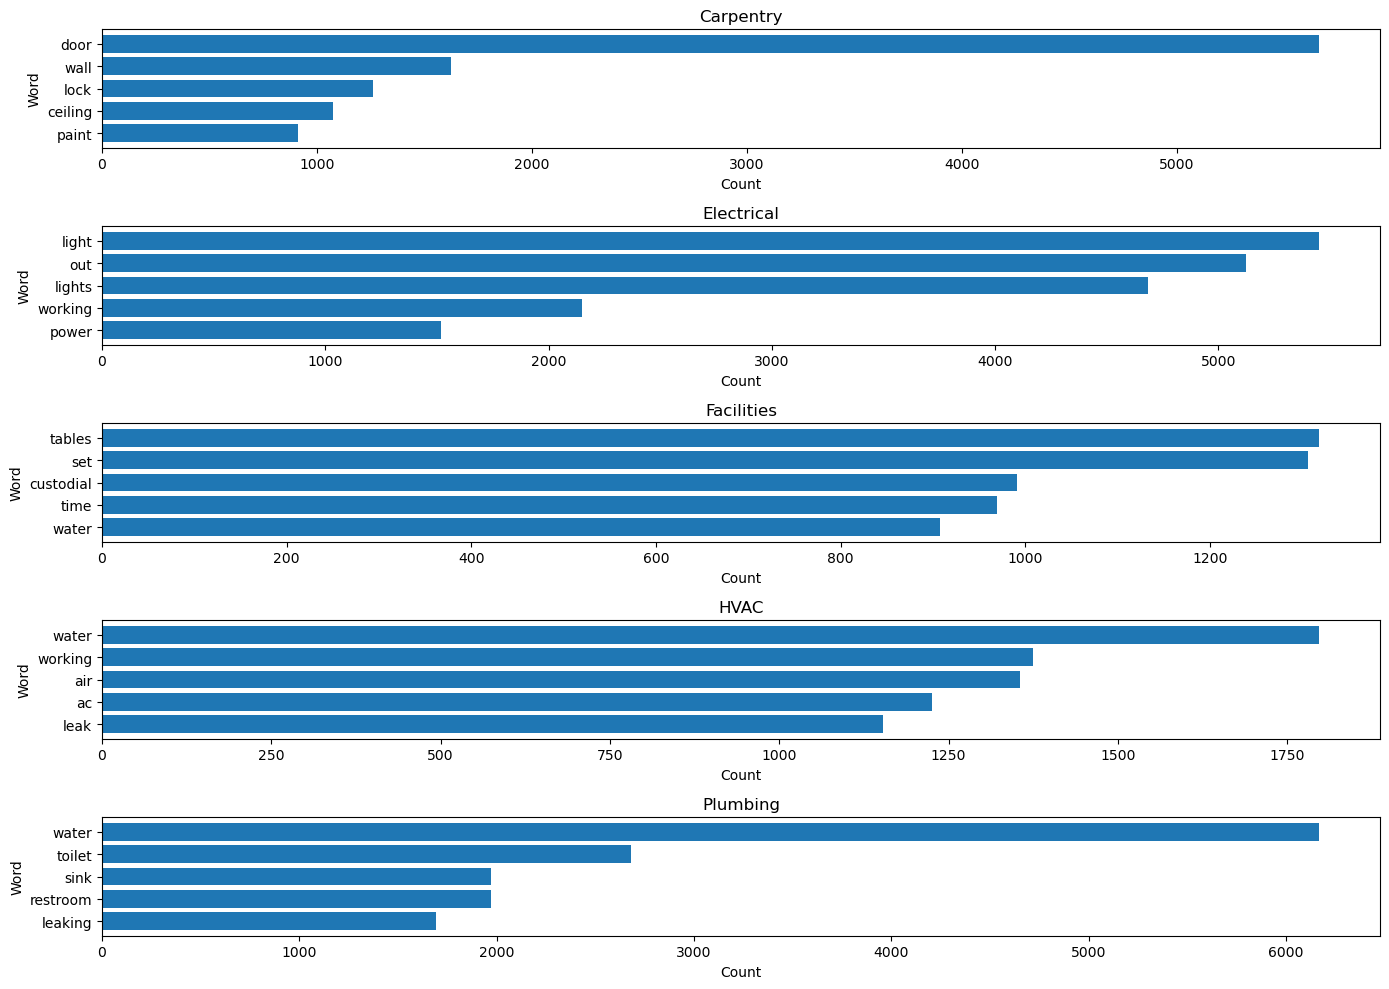

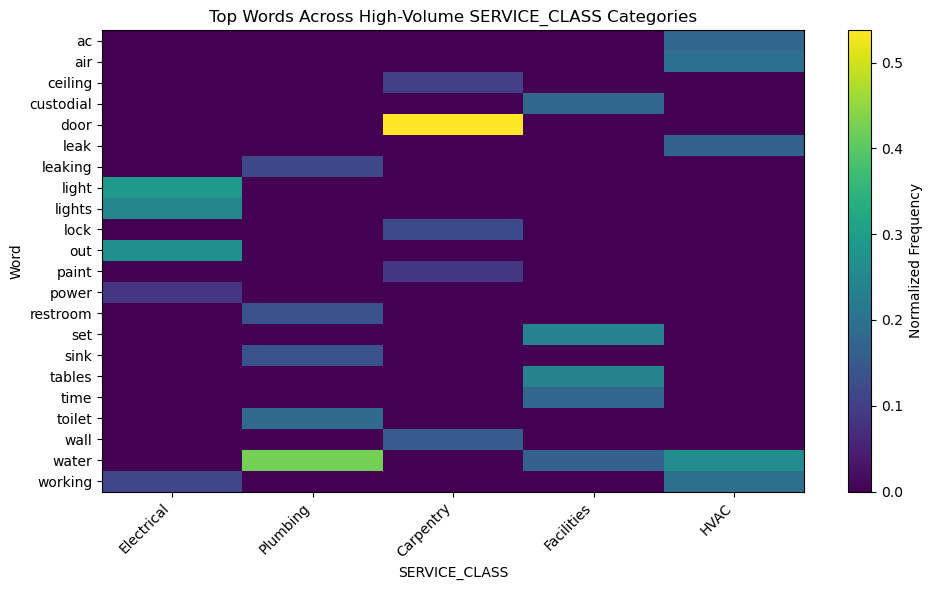

In [9]:
from sentiments import get_top_groups_by_volume, get_top_words_for_top_groups, plot_top_word_bars, plot_top_word_heatmap
# Plotting:
# REQUEST_CLASS
top_request_groups, top_request_words = get_top_words_for_top_groups(
    df_text,
    group_col="REQUEST_CLASS",
    top_k_groups=5,
    n_words=5
)

plot_top_word_bars(top_request_words, "REQUEST_CLASS")
request_heatmap = plot_top_word_heatmap(
    top_request_words,
    "REQUEST_CLASS",
    top_request_groups,
    normalize=True
)

# SERVICE_CLASS
top_service_groups, top_service_words = get_top_words_for_top_groups(
    df_text,
    group_col="SERVICE_CLASS",
    top_k_groups=5,
    n_words=5
)

plot_top_word_bars(top_service_words, "SERVICE_CLASS")
service_heatmap = plot_top_word_heatmap(
    top_service_words,
    "SERVICE_CLASS",
    top_service_groups,
    normalize=True
)